# Overfitting and Early Stopping

In the previous notebooks, we mostly asked whether a model could reduce its training loss. That is only the first question. In real modeling, especially with noisy measurements, the more important question is whether the model has learned a pattern that survives beyond the exact examples it saw.

This notebook studies that question through two connected examples:

1. a nonlinear ring-classification problem, where we can watch a small neural network become too specialized to its training points,
2. a physics calibration problem, where the same ideas appear as train/validation/test splits, model capacity, weight decay, early stopping, and dropout.

The key warning is:

$$
	ext{low training loss does not automatically mean good prediction.}
$$

A model **overfits** when it learns details that are useful for the training data but unreliable for new data. A model **generalizes** when it performs well on data that was held out during training.


## The basic workflow

We will separate the available data into two groups at first:

| Split | Used for | What it tells us |
|---|---|---|
| training data | updating the model weights | how well the model fits what it is allowed to see |
| validation data | choosing when to stop training | how well the model behaves on held-out examples |

During training, the training loss can keep falling simply because the model is getting better at the training points. The validation loss is the reality check. If validation loss stops improving while training loss keeps improving, the model is probably starting to memorize accidental details.

Early stopping is a practical response to that signal: keep the parameter values from the step with the best validation loss, instead of blindly using the final training step.


## Setup: data, model size, and plotting defaults

The first code cell creates a synthetic two-class dataset shaped like a ring. The class label depends on the radius of a point, so a straight line is not enough to separate the classes.

We also choose `Nneurons = 16`, which gives the neural network enough flexibility to bend its decision boundary. That flexibility is useful, but it is also what makes overfitting possible.


In [1]:
import random

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# Reproducibility
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


def make_ring_data(n=840, noise=0.08):
    """A simple nonlinear two-class dataset in dimensionless coordinates."""
    X = 2.6 * torch.rand(n, 2) - 1.3
    r = torch.sqrt((X ** 2).sum(dim=1))
    y = ((r > 0.55) & (r < 1.05)).float()
    X = X + noise * torch.randn_like(X)
    return X, y


X_ring, y_ring = make_ring_data()
Nneurons = 16

print("PyTorch version:", torch.__version__)
print(f"Ring dataset: {len(X_ring)} points")


PyTorch version: 2.2.2
Ring dataset: 840 points


## Training with a validation split

The next cell performs the whole early-stopping experiment.

The important pieces to track are:

- `X_ring_train`, `y_ring_train`: examples used by gradient descent,
- `X_ring_validation`, `y_ring_validation`: examples held out from weight updates,
- `train_losses`: loss on the training split over time,
- `validation_losses`: loss on the held-out split over time,
- `best_validation_state`: the model parameters from the best validation step.

Notice the asymmetry: the optimizer only sees the training loss. The validation loss is measured after each update, but it is not backpropagated through. That is what makes it useful as an independent check.


Training points: 672, validation points: 168
Max iterations: 3500
Best validation BCE: 0.277 at step 267
Early-stopping accuracy: train 0.911, validation 0.881
Max-iteration accuracy: train 0.915, validation 0.893


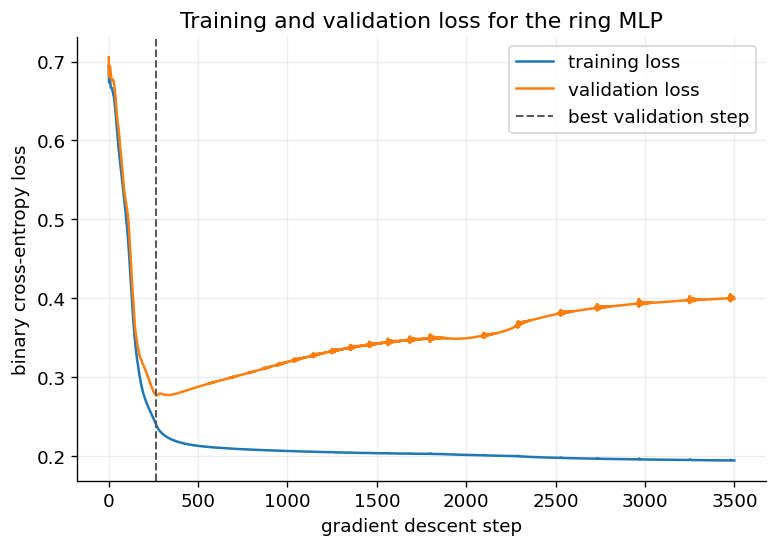

/var/folders/xs/7436fth96c550p00b17kx1q40000gn/T/ipykernel_47421/1161898908.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


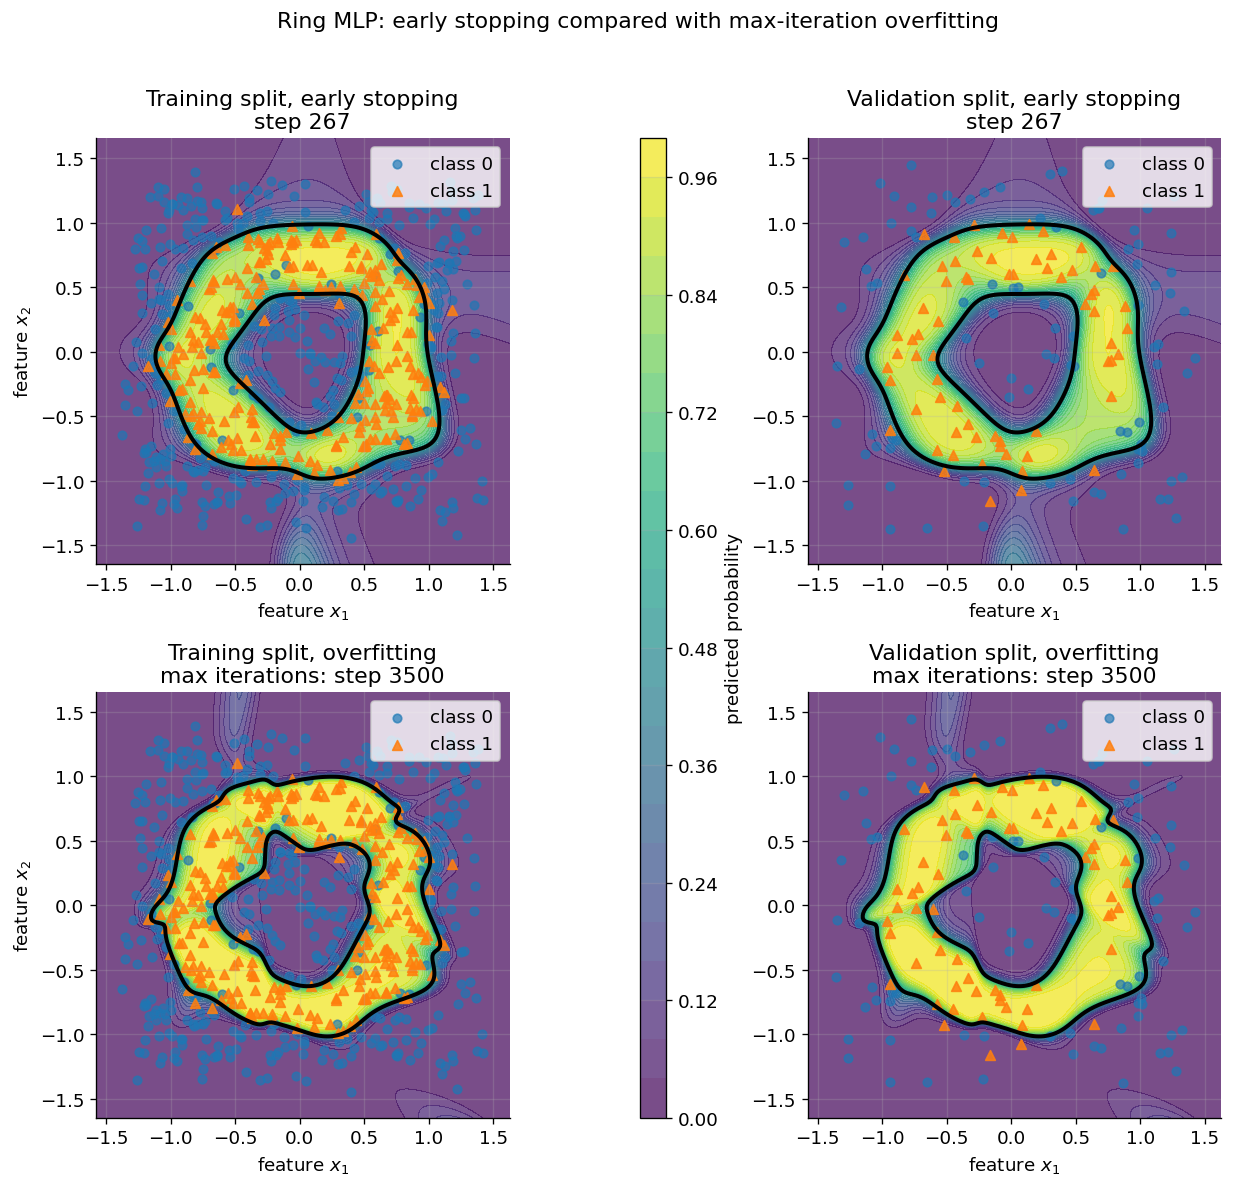

<All keys matched successfully>

In [2]:
# Train the ring MLP again with a separate validation set.
validation_fraction = 0.20
max_validation_steps = 3500
use_early_stopping = True
early_stopping_min_delta = 1e-4

validation_seed = 42
split_generator = torch.Generator().manual_seed(validation_seed)
indices = torch.randperm(len(X_ring), generator=split_generator)
n_validation = int(validation_fraction * len(indices))
validation_indices = indices[:n_validation]
train_indices = indices[n_validation:]

X_ring_train, y_ring_train = X_ring[train_indices], y_ring[train_indices]
X_ring_validation, y_ring_validation = X_ring[validation_indices], y_ring[validation_indices]

torch.manual_seed(validation_seed)
mlp_ring_validation = nn.Sequential(
    nn.Linear(2, Nneurons),
    nn.Tanh(),
    nn.Linear(Nneurons, 1),
)

validation_optimizer = torch.optim.AdamW(mlp_ring_validation.parameters(), lr=0.03)
validation_loss_fn = nn.BCEWithLogitsLoss()
train_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_validation_step = 0
best_validation_state = None

for step in range(1, max_validation_steps + 1):
    mlp_ring_validation.train()
    train_logits = mlp_ring_validation(X_ring_train).squeeze(-1)
    train_loss = validation_loss_fn(train_logits, y_ring_train)
    validation_optimizer.zero_grad()
    train_loss.backward()
    validation_optimizer.step()

    mlp_ring_validation.eval()
    with torch.no_grad():
        step_train_loss = validation_loss_fn(
            mlp_ring_validation(X_ring_train).squeeze(-1),
            y_ring_train,
        ).item()
        step_validation_loss = validation_loss_fn(
            mlp_ring_validation(X_ring_validation).squeeze(-1),
            y_ring_validation,
        ).item()

    train_losses.append(step_train_loss)
    validation_losses.append(step_validation_loss)

    if step_validation_loss < best_validation_loss - early_stopping_min_delta:
        best_validation_loss = step_validation_loss
        best_validation_step = step
        best_validation_state = {
            name: value.detach().clone()
            for name, value in mlp_ring_validation.state_dict().items()
        }

max_iteration_state = {
    name: value.detach().clone()
    for name, value in mlp_ring_validation.state_dict().items()
}

if use_early_stopping and best_validation_state is not None:
    early_stopping_state = best_validation_state
    early_stopping_step = best_validation_step
else:
    early_stopping_state = max_iteration_state
    early_stopping_step = max_validation_steps


def accuracy_for_state(state, X_split, y_split):
    mlp_ring_validation.load_state_dict(state)
    with torch.no_grad():
        predictions = (torch.sigmoid(mlp_ring_validation(X_split).squeeze(-1)) > 0.5).float()
    return (predictions == y_split).float().mean().item()


early_train_accuracy = accuracy_for_state(early_stopping_state, X_ring_train, y_ring_train)
early_validation_accuracy = accuracy_for_state(early_stopping_state, X_ring_validation, y_ring_validation)
max_train_accuracy = accuracy_for_state(max_iteration_state, X_ring_train, y_ring_train)
max_validation_accuracy = accuracy_for_state(max_iteration_state, X_ring_validation, y_ring_validation)

print(f"Training points: {len(train_indices)}, validation points: {len(validation_indices)}")
print(f"Max iterations: {max_validation_steps}")
print(f"Best validation BCE: {best_validation_loss:.3f} at step {best_validation_step}")
print(
    f"Early-stopping accuracy: train {early_train_accuracy:.3f}, "
    f"validation {early_validation_accuracy:.3f}"
)
print(
    f"Max-iteration accuracy: train {max_train_accuracy:.3f}, "
    f"validation {max_validation_accuracy:.3f}"
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
steps_run = np.arange(1, len(train_losses) + 1)
ax.plot(steps_run, train_losses, label="training loss")
ax.plot(steps_run, validation_losses, label="validation loss")
ax.axvline(best_validation_step, color="0.35", linestyle="--", linewidth=1.2, label="best validation step")
ax.set_xlabel("gradient descent step")
ax.set_ylabel("binary cross-entropy loss")
ax.set_title("Training and validation loss for the ring MLP")
ax.grid(alpha=0.22)
ax.legend()
plt.show()

x1_min = X_ring[:, 0].min().item() - 0.2
x1_max = X_ring[:, 0].max().item() + 0.2
x2_min = X_ring[:, 1].min().item() - 0.2
x2_max = X_ring[:, 1].max().item() + 0.2
x1_validation_grid = torch.linspace(x1_min, x1_max, 180)
x2_validation_grid = torch.linspace(x2_min, x2_max, 180)
XX_validation, YY_validation = torch.meshgrid(
    x1_validation_grid,
    x2_validation_grid,
    indexing="xy",
)
ring_validation_grid = torch.stack(
    [XX_validation.reshape(-1), YY_validation.reshape(-1)],
    dim=1,
)


def probability_grid_for_state(state):
    mlp_ring_validation.load_state_dict(state)
    with torch.no_grad():
        return torch.sigmoid(
            mlp_ring_validation(ring_validation_grid).squeeze(-1)
        ).reshape(XX_validation.shape)


early_probability_grid = probability_grid_for_state(early_stopping_state)
max_probability_grid = probability_grid_for_state(max_iteration_state)


def plot_validation_split_panel(ax, probability_grid, X_split, y_split, title, show_ylabel=True):
    im = ax.contourf(
        XX_validation.numpy(),
        YY_validation.numpy(),
        probability_grid.numpy(),
        levels=25,
        alpha=0.72,
    )
    ax.contour(
        XX_validation.numpy(),
        YY_validation.numpy(),
        probability_grid.numpy(),
        levels=[0.5],
        colors="black",
        linewidths=2.4,
    )
    y_split_np = y_split.numpy().astype(int)
    ax.scatter(
        X_split[y_split_np == 0, 0],
        X_split[y_split_np == 0, 1],
        s=26,
        alpha=0.68,
        label="class 0",
    )
    ax.scatter(
        X_split[y_split_np == 1, 0],
        X_split[y_split_np == 1, 1],
        s=34,
        marker="^",
        alpha=0.84,
        label="class 1",
    )
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_xlabel("feature $x_1$")
    if show_ylabel:
        ax.set_ylabel("feature $x_2$")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=True, loc="upper right")
    return im

fig = plt.figure(figsize=(13.8, 10.6))
grid_spec = fig.add_gridspec(
    2,
    5,
    width_ratios=[1, 0.09, 0.045, 0.11, 1],
    hspace=0.30,
    wspace=0.0,
)
train_early_ax = fig.add_subplot(grid_spec[0, 0])
validation_early_ax = fig.add_subplot(grid_spec[0, 4], sharex=train_early_ax, sharey=train_early_ax)
train_max_ax = fig.add_subplot(grid_spec[1, 0], sharex=train_early_ax, sharey=train_early_ax)
validation_max_ax = fig.add_subplot(grid_spec[1, 4], sharex=train_early_ax, sharey=train_early_ax)
colorbar_ax = fig.add_subplot(grid_spec[:, 2])

im = plot_validation_split_panel(
    train_early_ax,
    early_probability_grid,
    X_ring_train,
    y_ring_train,
    f"Training split, early stopping\nstep {early_stopping_step}",
)
plot_validation_split_panel(
    validation_early_ax,
    early_probability_grid,
    X_ring_validation,
    y_ring_validation,
    f"Validation split, early stopping\nstep {early_stopping_step}",
    show_ylabel=False,
)
plot_validation_split_panel(
    train_max_ax,
    max_probability_grid,
    X_ring_train,
    y_ring_train,
    f"Training split, overfitting\nmax iterations: step {max_validation_steps}",
)
plot_validation_split_panel(
    validation_max_ax,
    max_probability_grid,
    X_ring_validation,
    y_ring_validation,
    f"Validation split, overfitting\nmax iterations: step {max_validation_steps}",
    show_ylabel=False,
)

cbar = fig.colorbar(im, cax=colorbar_ax)
cbar.set_label("predicted probability")
fig.suptitle("Ring MLP: early stopping compared with max-iteration overfitting")
plt.tight_layout()
plt.show()

mlp_ring_validation.load_state_dict(early_stopping_state)


## Reading the result

After training, compare two models:

1. the **early-stopped model**, restored from the best validation step,
2. the **final-step model**, obtained after all allowed optimization steps.

If the final-step model has lower training loss but worse validation loss, it is not really better. It has simply become more tailored to the training split. In the decision-boundary plot, this often appears as extra bends or small regions that chase individual points.


# Summary

The training loss measures how well the model fits the points used for optimization. The validation loss measures how well the same model works on held-out points.

When the training loss keeps decreasing but the validation loss stops improving, the model is beginning to specialize too much to the training split. That is the overfitting signal.

Early stopping keeps the parameter state from the best validation step. The max-iteration model shows what happens if we continue optimizing after that point.


# Exercises

1. Increase `max_validation_steps`. Does the max-iteration boundary become more complicated?

2. Change `Nneurons` in the setup cell. How does model capacity affect the gap between training and validation loss?

3. Increase the noise in `make_ring_data`. Does early stopping happen earlier or later?

4. Set `use_early_stopping = False`. Which state is used as the early-stopping comparison?

5. Try `Adam` instead of `AdamW`. Does the overfitting pattern change?


## From the ring example to physics data

The ring dataset is useful because the geometry is easy to see: the decision boundary either captures the ring structure or it starts chasing individual samples.

The same problem appears in physics calibration, but it can be more subtle. A curve can pass very close to the measured training points while still giving bad predictions between them or at new voltages. The next part of the notebook makes that version of overfitting explicit.


---

# Generalization and Regularization

The ring example shows the mechanism of overfitting in a classifier: a flexible model can keep improving its training objective while becoming less reliable on held-out data.

The continuation below uses a physics calibration problem to make the same ideas more concrete. Instead of class labels, we predict a measured magnetic field from a control voltage. This lets us discuss:

- train/validation/test splits,
- underfitting versus overfitting,
- model capacity,
- L2 regularization / weight decay,
- early stopping,
- dropout.

The examples start with polynomial regression because the fitted curves are easy to interpret, then return to neural networks in PyTorch.


## Physics calibration example

## When a neural network learns the data but not the law

In the previous lessons we built models and trained them by minimizing a loss.  
Today we ask a deeper question:

> If the training loss is small, did the model really learn the physical law?

We will use a physics-style calibration experiment:

- the input is a control voltage $V$ measured in volts,
- the target is a magnetic field $B$ measured in millitesla,
- the measurements are noisy,
- the goal is to predict $B$ for **new voltages** that were not used during training.

The central idea is:

$$
\text{learning} \neq \text{memorizing}.
$$

A useful model should have small error on **unseen data**, not only on the data used to fit it.

## Learning goals

By the end of this notebook you should be able to explain:

1. why we split data into training, validation, and test sets,
2. what overfitting and underfitting look like,
3. why increasing model capacity can be dangerous,
4. how weight decay regularization works,
5. how early stopping uses validation data,
6. how the same ideas apply to neural networks.

The notebook uses PyTorch throughout, but the first examples are deliberately simple and visual.

In [3]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Use float64 for stable polynomial least-squares experiments.
torch.set_default_dtype(torch.float64)
# Small networks train faster and more predictably with one CPU thread in notebooks.
torch.set_num_threads(1)

# Simple plotting defaults for readability in class.
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


---

# 1. A small calibration experiment

Suppose we are calibrating a laboratory device.  
A voltage $V$ controls a magnetic field $B$.

The true relation is not exactly linear.  
There is also measurement noise:

$$
B_i = f(V_i) + \epsilon_i,
\qquad
\epsilon_i \sim \mathcal{N}(0, \sigma^2).
$$

The model never sees the true function $f$.  
It only sees a finite number of noisy measurements.

In [4]:
def true_field(V):
    """True magnetic field B(V) in millitesla.

    V is measured in volts.
    B is measured in millitesla.
    """
    return 20.0 + 45.0*V - 12.0*V**2 + 4.0*torch.sin(2*math.pi*V)

# Dense grid for drawing the hidden true law.
V_grid = torch.linspace(0.0, 1.0, 400).reshape(-1, 1)
B_true_grid = true_field(V_grid)

# Sparse, noisy experimental measurements.
n_total = 44
V_all = torch.linspace(0.02, 0.98, n_total).reshape(-1, 1)
V_all = V_all + 0.01*torch.randn_like(V_all)
V_all = torch.clamp(V_all, 0.0, 1.0)
noise_sigma = 2.2  # mT
B_all = true_field(V_all) + noise_sigma*torch.randn_like(V_all)

# Random train / validation / test split.
perm = torch.randperm(n_total)
train_idx = perm[:20]
val_idx = perm[20:32]
test_idx = perm[32:]

V_train, B_train = V_all[train_idx], B_all[train_idx]
V_val, B_val = V_all[val_idx], B_all[val_idx]
V_test, B_test = V_all[test_idx], B_all[test_idx]

print(f"Training points:   {len(V_train)}")
print(f"Validation points: {len(V_val)}")
print(f"Test points:       {len(V_test)}")

Training points:   20
Validation points: 12
Test points:       12


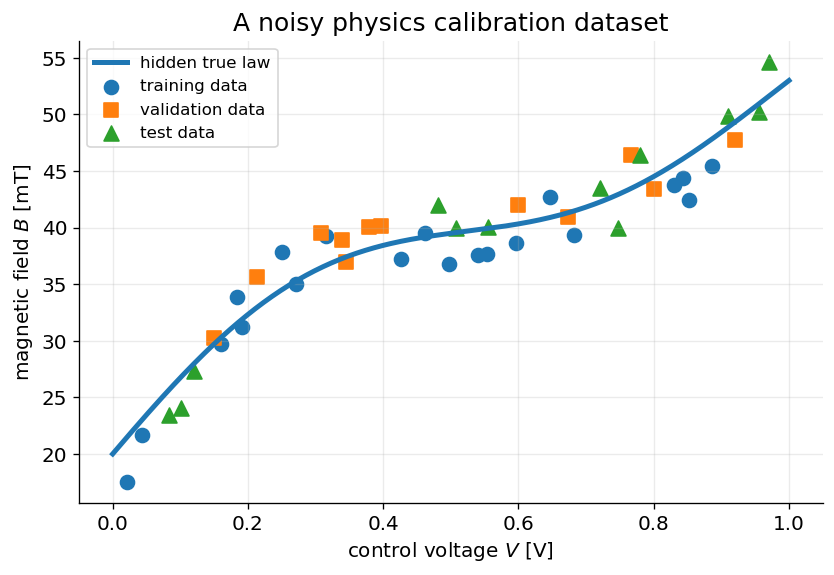

In [5]:
plt.figure()
plt.plot(V_grid, B_true_grid, linewidth=3, label="hidden true law")
plt.scatter(V_train, B_train, s=70, label="training data")
plt.scatter(V_val, B_val, s=70, marker="s", label="validation data")
plt.scatter(V_test, B_test, s=80, marker="^", label="test data")
plt.xlabel("control voltage $V$ [V]")
plt.ylabel("magnetic field $B$ [mT]")
plt.title("A noisy physics calibration dataset")
plt.legend()
plt.show()

The split has three different roles:

| Dataset | Used for | Meaning |
|---|---|---|
| training set | fitting the parameters | data the model is allowed to learn from |
| validation set | choosing model complexity or hyperparameters | a proxy for unseen data |
| test set | final evaluation | data untouched until the end |

The validation set is not used directly to update the weights.  
It is used to decide questions such as:

- Is the model too simple?
- Is the model too flexible?
- What regularization strength should we use?
- When should training stop?

---

# 2. Underfitting and overfitting with polynomial models

Before using neural networks, let us use a very transparent family of models:

$$
\hat{B}(V) = w_0 + w_1 z + w_2 z^2 + \cdots + w_d z^d,
$$

where $z$ is a rescaled version of the voltage:

$$
z = 2V - 1.
$$

The integer $d$ is the polynomial degree.  
It controls the **capacity** of the model.

- Small $d$: the model may be too rigid.
- Large $d$: the model may become too flexible.

The loss used for training is the mean squared error:

$$
\mathcal{L}_{\mathrm{MSE}}
=
\frac{1}{N}\sum_{i=1}^{N}\left(\hat{B}_i-B_i\right)^2.
$$

Since $B$ is measured in millitesla, the MSE has units of $\mathrm{mT}^2$.

In [6]:
def voltage_to_z(V):
    """Map V in [0,1] to z in [-1,1]."""
    return 2.0*V - 1.0

def polynomial_features(V, degree):
    """Return [1, z, z^2, ..., z^degree]."""
    z = voltage_to_z(V)
    return torch.cat([z**p for p in range(degree + 1)], dim=1)

def fit_polynomial_closed_form(V, B, degree, ridge_lambda=0.0):
    """Fit polynomial using linear least squares with optional L2 penalty.

    The bias coefficient w0 is not penalized.
    """
    X = polynomial_features(V, degree)
    n_features = X.shape[1]
    I = torch.eye(n_features, dtype=X.dtype)
    I[0, 0] = 0.0  # do not penalize the bias term
    w = torch.linalg.solve(X.T @ X + ridge_lambda*I, X.T @ B)
    return w

def predict_polynomial(V, w):
    degree = len(w) - 1
    X = polynomial_features(V, degree)
    return X @ w

def mse(y_hat, y):
    return torch.mean((y_hat - y)**2).item()

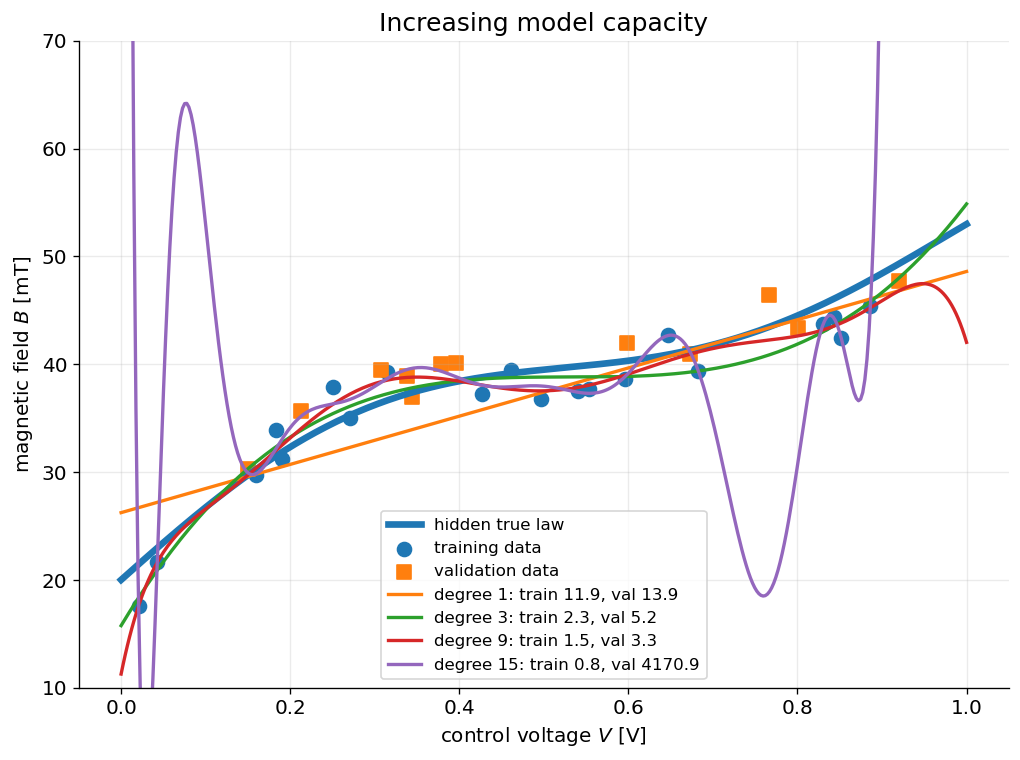

In [7]:
degrees = [1, 3, 9, 15]
fits = {}

for degree in degrees:
    w = fit_polynomial_closed_form(V_train, B_train, degree)
    fits[degree] = w

plt.figure(figsize=(10, 7))
plt.plot(V_grid, B_true_grid, linewidth=4, label="hidden true law")
plt.scatter(V_train, B_train, s=70, label="training data")
plt.scatter(V_val, B_val, s=70, marker="s", label="validation data")

for degree, w in fits.items():
    B_pred_grid = predict_polynomial(V_grid, w)
    train_mse = mse(predict_polynomial(V_train, w), B_train)
    val_mse = mse(predict_polynomial(V_val, w), B_val)
    plt.plot(V_grid, B_pred_grid, linewidth=2,
             label=f"degree {degree}: train {train_mse:.1f}, val {val_mse:.1f}")

plt.xlabel("control voltage $V$ [V]")
plt.ylabel("magnetic field $B$ [mT]")
plt.title("Increasing model capacity")
plt.ylim(10, 70)
plt.legend(loc="best")
plt.show()

## What to notice

A model can have a very small training error but still behave badly between measurements.

That is overfitting:

$$
\text{training error small}, \qquad \text{validation error large}.
$$

A useful model must generalize:

$$
\text{good performance on data not used for fitting.}
$$

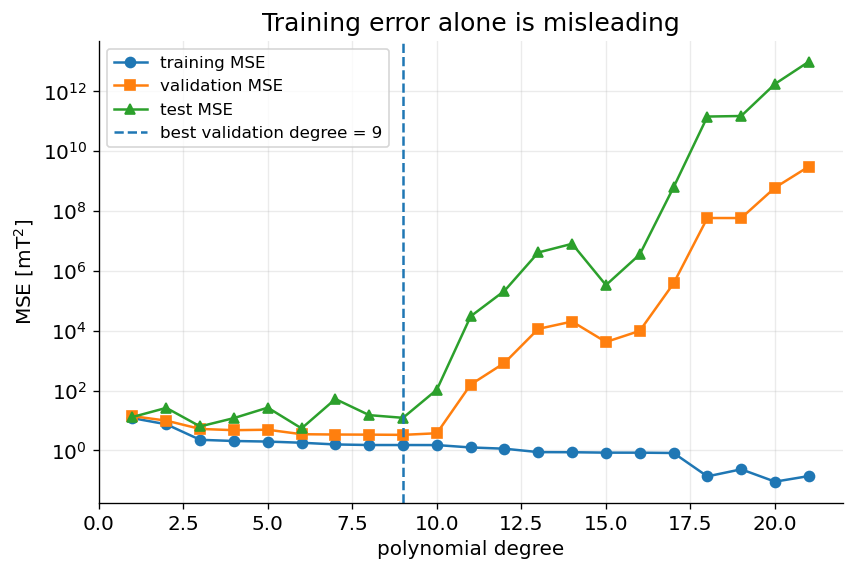

Best degree by validation MSE: 9
Validation MSE at best degree: 3.30 mT^2


In [8]:
all_degrees = list(range(1, 22))
train_errors = []
val_errors = []
test_errors = []

for degree in all_degrees:
    w = fit_polynomial_closed_form(V_train, B_train, degree)
    train_errors.append(mse(predict_polynomial(V_train, w), B_train))
    val_errors.append(mse(predict_polynomial(V_val, w), B_val))
    test_errors.append(mse(predict_polynomial(V_test, w), B_test))

best_degree = all_degrees[int(np.argmin(val_errors))]

plt.figure()
plt.plot(all_degrees, train_errors, marker="o", label="training MSE")
plt.plot(all_degrees, val_errors, marker="s", label="validation MSE")
plt.plot(all_degrees, test_errors, marker="^", label="test MSE")
plt.axvline(best_degree, linestyle="--", label=f"best validation degree = {best_degree}")
plt.xlabel("polynomial degree")
plt.ylabel("MSE [$\\mathrm{mT}^2$]")
plt.title("Training error alone is misleading")
plt.yscale("log")
plt.legend()
plt.show()

print(f"Best degree by validation MSE: {best_degree}")
print(f"Validation MSE at best degree: {min(val_errors):.2f} mT^2")

The usual pattern is:

- **underfitting**: both training and validation errors are large,
- **good generalization**: both errors are reasonably small,
- **overfitting**: training error keeps decreasing but validation error increases.

This is one of the most important diagnostic plots in machine learning.

---

# 3. Regularization: prefer simpler explanations

A high-degree polynomial can wiggle violently.  
One way to control this is to penalize large coefficients.

Instead of minimizing only

$$
\mathcal{L}_{\mathrm{data}}
=
\frac{1}{N}\sum_{i=1}^{N}(\hat{B}_i-B_i)^2,
$$

we minimize

$$
\mathcal{L}_{\mathrm{reg}}
=
\mathcal{L}_{\mathrm{data}}
+
\lambda \sum_{j=1}^{d} w_j^2.
$$

This is called **L2 regularization** or **weight decay**.

The parameter $\lambda$ controls how strongly we penalize large weights.

Important detail: here we do not penalize the bias term $w_0$.

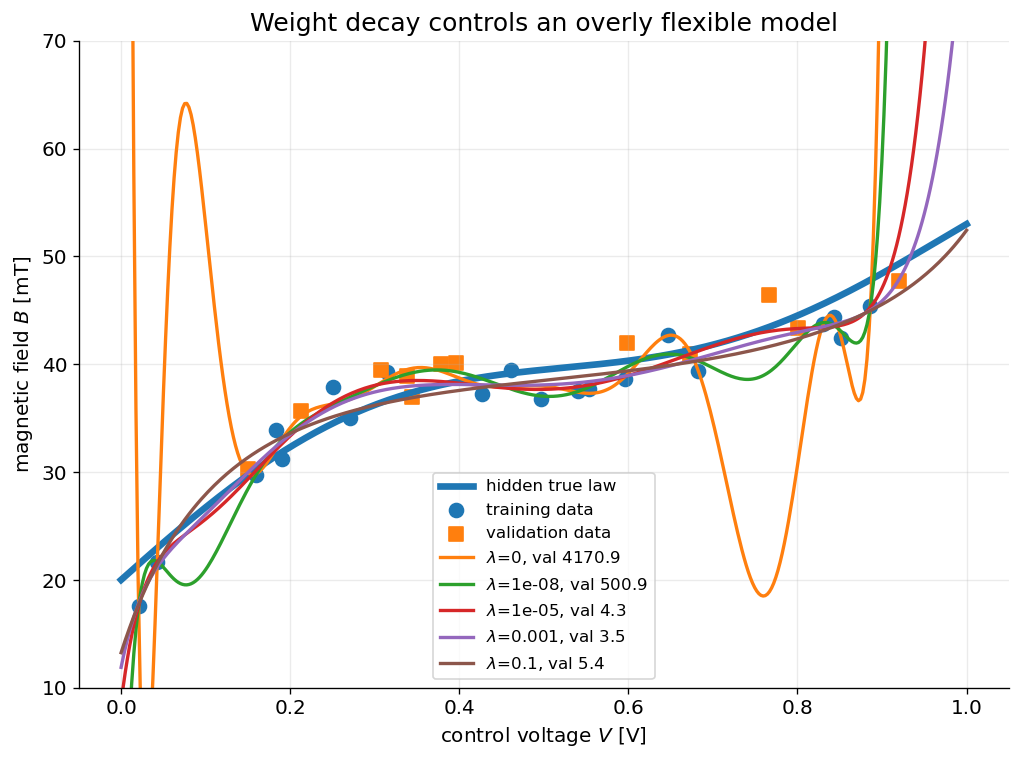

lambda       train MSE    val MSE      ||w_without_bias||
  0.0e+00       0.840    4170.927    1280806.643
  1.0e-08       1.195     500.929      10429.143
  1.0e-05       1.510       4.260        131.635
  1.0e-03       1.664       3.471         57.511
  1.0e-01       2.308       5.371          9.644


In [9]:
degree = 15
lambdas = [0.0, 1e-8, 1e-5, 1e-3, 1e-1]

plt.figure(figsize=(10, 7))
plt.plot(V_grid, B_true_grid, linewidth=4, label="hidden true law")
plt.scatter(V_train, B_train, s=70, label="training data")
plt.scatter(V_val, B_val, s=70, marker="s", label="validation data")

results = []
for lam in lambdas:
    w = fit_polynomial_closed_form(V_train, B_train, degree, ridge_lambda=lam)
    B_pred_grid = predict_polynomial(V_grid, w)
    train_mse = mse(predict_polynomial(V_train, w), B_train)
    val_mse = mse(predict_polynomial(V_val, w), B_val)
    weight_norm = torch.linalg.norm(w[1:]).item()
    results.append((lam, train_mse, val_mse, weight_norm))
    plt.plot(V_grid, B_pred_grid, linewidth=2,
             label=f"$\\lambda$={lam:g}, val {val_mse:.1f}")

plt.xlabel("control voltage $V$ [V]")
plt.ylabel("magnetic field $B$ [mT]")
plt.title("Weight decay controls an overly flexible model")
plt.ylim(10, 70)
plt.legend(loc="best")
plt.show()

print("lambda       train MSE    val MSE      ||w_without_bias||")
for lam, tr, va, wn in results:
    print(f"{lam:9.1e}   {tr:9.3f}   {va:9.3f}   {wn:12.3f}")

Weight decay expresses a useful bias:

> Among models that explain the data, prefer the smoother one with smaller weights.

This resembles many ideas in physics and numerical analysis:

- avoid fitting measurement noise,
- prefer stable solutions,
- penalize unnecessarily large parameters,
- control ill-conditioned inverse problems.

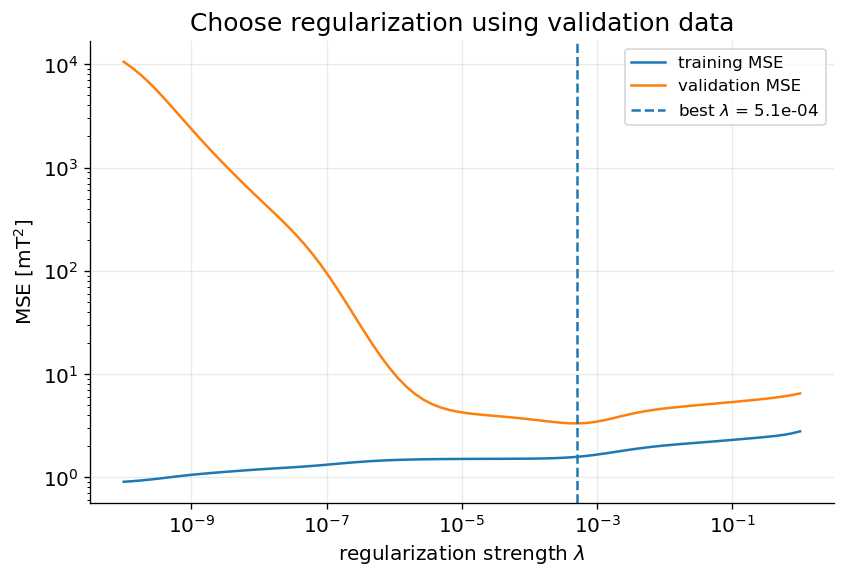

In [10]:
# Validation curve for the regularization strength.
lambda_grid = torch.logspace(-10, 0, 80)
val_by_lambda = []
train_by_lambda = []
weight_norm_by_lambda = []

for lam in lambda_grid:
    w = fit_polynomial_closed_form(V_train, B_train, degree, ridge_lambda=float(lam))
    train_by_lambda.append(mse(predict_polynomial(V_train, w), B_train))
    val_by_lambda.append(mse(predict_polynomial(V_val, w), B_val))
    weight_norm_by_lambda.append(torch.linalg.norm(w[1:]).item())

best_lambda = float(lambda_grid[int(np.argmin(val_by_lambda))])

plt.figure()
plt.plot(lambda_grid.numpy(), train_by_lambda, label="training MSE")
plt.plot(lambda_grid.numpy(), val_by_lambda, label="validation MSE")
plt.axvline(best_lambda, linestyle="--", label=f"best $\\lambda$ = {best_lambda:.1e}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("regularization strength $\\lambda$")
plt.ylabel("MSE [$\\mathrm{mT}^2$]")
plt.title("Choose regularization using validation data")
plt.legend()
plt.show()

---

# 4. The PyTorch view: weight decay in an optimizer

In PyTorch, weight decay is often added through the optimizer:

```python
optimizer = torch.optim.Adam(model.parameters(), lr=..., weight_decay=...)
```

For many common optimizers, this adds a penalty that discourages large weights.

Let us now fit the same calibration data using a small neural network.

## Preparing data for neural network training

Neural networks usually train more reliably when inputs and targets have convenient scales.

We use

$$
V \mapsto z = 2V-1
$$

and we standardize the target using the training data:

$$
B_{\mathrm{scaled}} = \frac{B - \mu_B}{s_B}.
$$

After prediction, we transform back to millitesla.

In [11]:
B_mean = B_train.mean()
B_std = B_train.std()

def scale_input(V):
    return voltage_to_z(V)

def scale_target(B):
    return (B - B_mean) / B_std

def unscale_target(B_scaled):
    return B_scaled * B_std + B_mean

x_train = scale_input(V_train)
y_train = scale_target(B_train)
x_val = scale_input(V_val)
y_val = scale_target(B_val)
x_test = scale_input(V_test)
y_test = scale_target(B_test)
x_grid = scale_input(V_grid)

In [12]:
class SmallMLP(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_model(weight_decay=0.0, epochs=700, lr=0.01):
    model = SmallMLP(hidden=48)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_loss_mT2 = mse(unscale_target(model(x_train)), B_train)
            val_loss_mT2 = mse(unscale_target(model(x_val)), B_val)

        train_losses.append(train_loss_mT2)
        val_losses.append(val_loss_mT2)

    return model, np.array(train_losses), np.array(val_losses)

model_no_reg, train_no_reg, val_no_reg = train_model(weight_decay=0.0)
model_decay, train_decay, val_decay = train_model(weight_decay=1e-3)

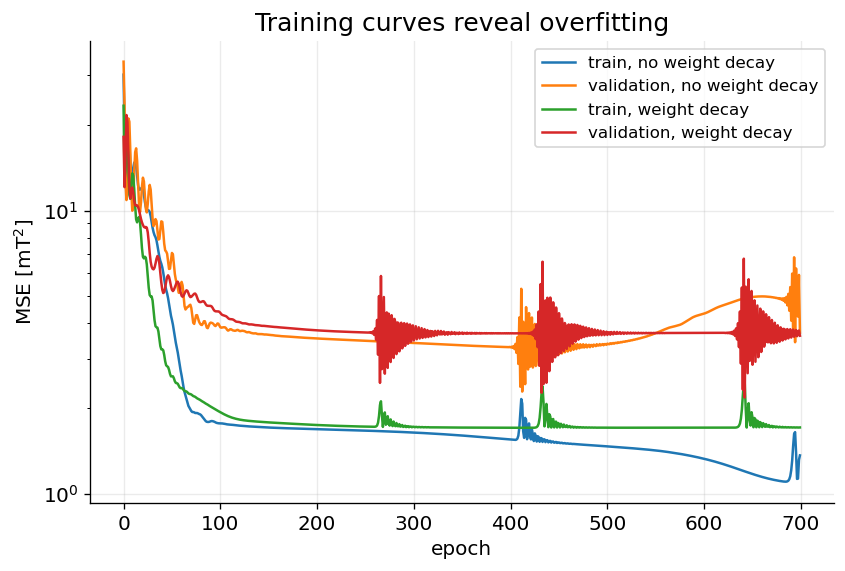

No weight decay: final train MSE = 1.37, final val MSE = 3.70 mT^2
With weight decay: final train MSE = 1.71, final val MSE = 3.61 mT^2


In [13]:
plt.figure()
plt.plot(train_no_reg, label="train, no weight decay")
plt.plot(val_no_reg, label="validation, no weight decay")
plt.plot(train_decay, label="train, weight decay")
plt.plot(val_decay, label="validation, weight decay")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE [$\\mathrm{mT}^2$]")
plt.title("Training curves reveal overfitting")
plt.legend()
plt.show()

print(f"No weight decay: final train MSE = {train_no_reg[-1]:.2f}, final val MSE = {val_no_reg[-1]:.2f} mT^2")
print(f"With weight decay: final train MSE = {train_decay[-1]:.2f}, final val MSE = {val_decay[-1]:.2f} mT^2")

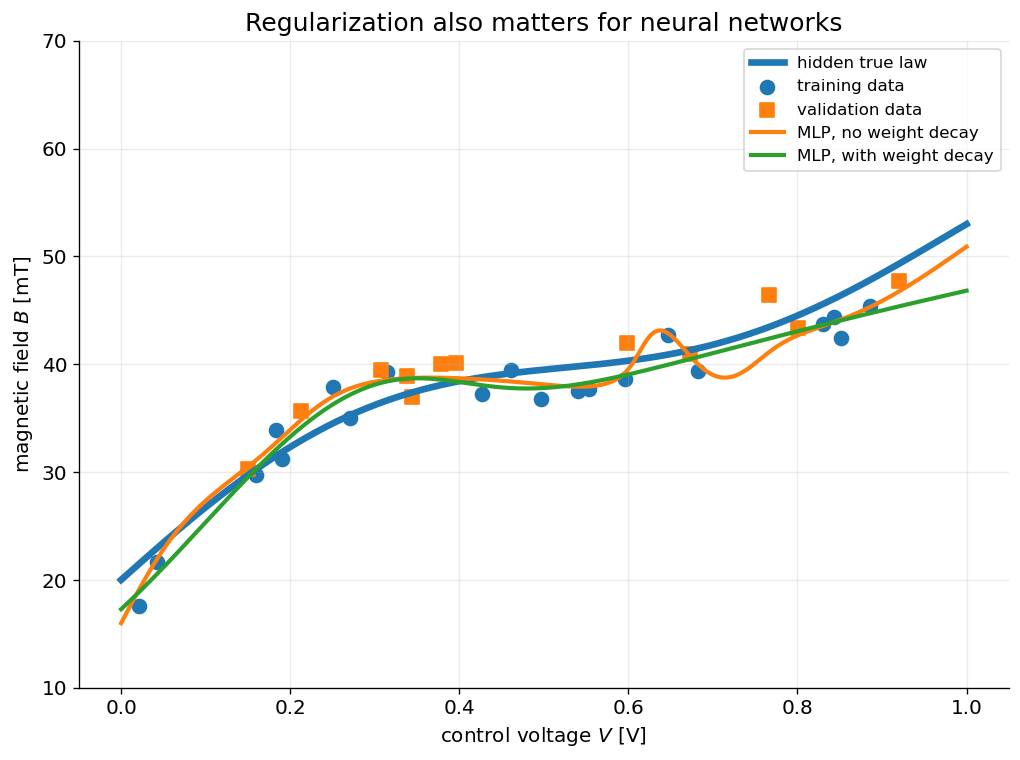

In [14]:
def predict_mlp_mT(model, V):
    model.eval()
    with torch.no_grad():
        return unscale_target(model(scale_input(V)))

plt.figure(figsize=(10, 7))
plt.plot(V_grid, B_true_grid, linewidth=4, label="hidden true law")
plt.scatter(V_train, B_train, s=70, label="training data")
plt.scatter(V_val, B_val, s=70, marker="s", label="validation data")
plt.plot(V_grid, predict_mlp_mT(model_no_reg, V_grid), linewidth=2.5, label="MLP, no weight decay")
plt.plot(V_grid, predict_mlp_mT(model_decay, V_grid), linewidth=2.5, label="MLP, with weight decay")
plt.xlabel("control voltage $V$ [V]")
plt.ylabel("magnetic field $B$ [mT]")
plt.title("Regularization also matters for neural networks")
plt.ylim(10, 70)
plt.legend()
plt.show()

The neural network has many more parameters than the polynomial models.  
That makes it powerful, but also risky.

A large network can fit complicated functions.  
With too little data, it can also fit noise.

Regularization is not a trick.  
It is part of the modeling choice.

---

# 5. Early stopping

Another way to reduce overfitting is to stop training when validation performance stops improving.

During training, we monitor:

$$
\mathcal{L}_{\mathrm{train}}(t),
\qquad
\mathcal{L}_{\mathrm{val}}(t).
$$

Early stopping chooses the epoch

$$
t_\star = \arg\min_t \mathcal{L}_{\mathrm{val}}(t).
$$

Then we keep the parameters from that epoch.

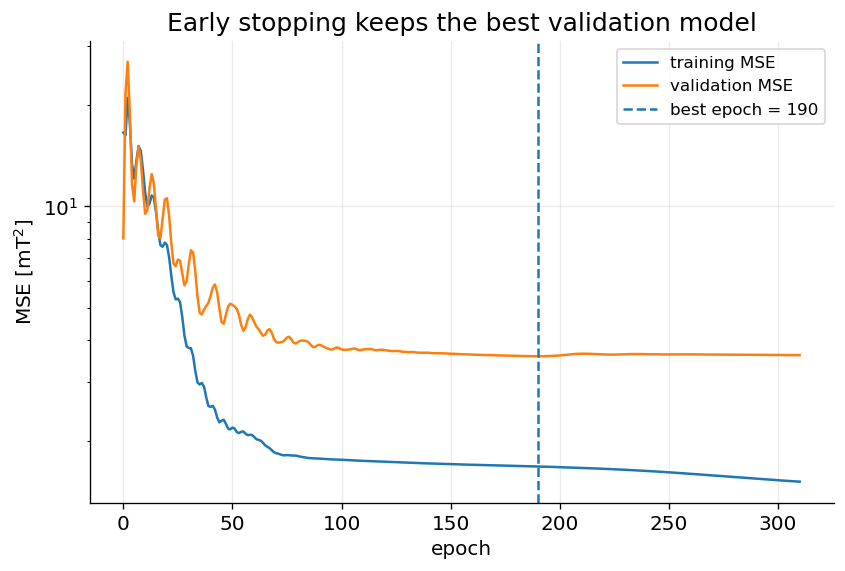

Stopped after 311 epochs.
Best validation epoch: 190
Best validation MSE: 3.58 mT^2


In [15]:
def train_with_early_stopping(max_epochs=1200, lr=0.01, patience=120):
    model = SmallMLP(hidden=64)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

    best_state = None
    best_val = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(x_train), y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_mT2 = mse(unscale_target(model(x_train)), B_train)
            val_mT2 = mse(unscale_target(model(x_val)), B_val)

        train_losses.append(train_mT2)
        val_losses.append(val_mT2)

        if val_mT2 < best_val:
            best_val = val_mT2
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    return model, np.array(train_losses), np.array(val_losses), best_epoch

model_early, train_early, val_early, best_epoch = train_with_early_stopping()

plt.figure()
plt.plot(train_early, label="training MSE")
plt.plot(val_early, label="validation MSE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE [$\\mathrm{mT}^2$]")
plt.title("Early stopping keeps the best validation model")
plt.legend()
plt.show()

print(f"Stopped after {len(train_early)} epochs.")
print(f"Best validation epoch: {best_epoch}")
print(f"Best validation MSE: {val_early[best_epoch]:.2f} mT^2")

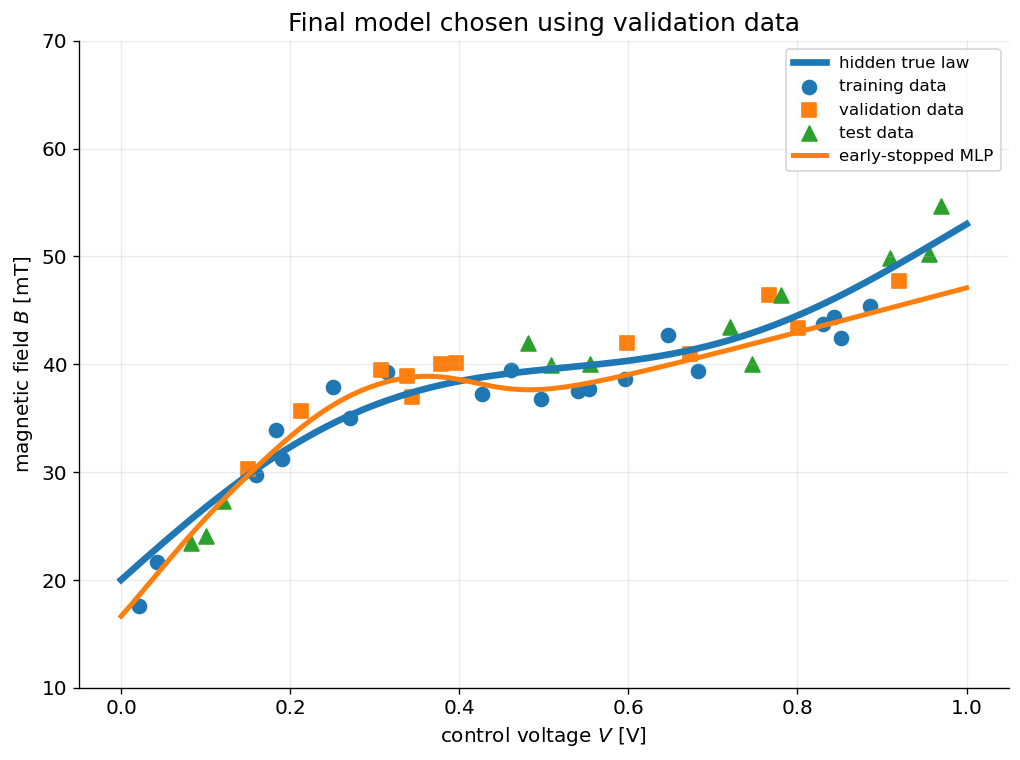

Final test MSE: 13.17 mT^2


In [16]:
plt.figure(figsize=(10, 7))
plt.plot(V_grid, B_true_grid, linewidth=4, label="hidden true law")
plt.scatter(V_train, B_train, s=70, label="training data")
plt.scatter(V_val, B_val, s=70, marker="s", label="validation data")
plt.scatter(V_test, B_test, s=80, marker="^", label="test data")
plt.plot(V_grid, predict_mlp_mT(model_early, V_grid), linewidth=3, label="early-stopped MLP")
plt.xlabel("control voltage $V$ [V]")
plt.ylabel("magnetic field $B$ [mT]")
plt.title("Final model chosen using validation data")
plt.ylim(10, 70)
plt.legend()
plt.show()

with torch.no_grad():
    test_mse = mse(predict_mlp_mT(model_early, V_test), B_test)
print(f"Final test MSE: {test_mse:.2f} mT^2")

## Important warning about the test set

The test set should be used only at the end.

If we repeatedly look at the test set while designing the model, it effectively becomes another validation set.  
Then the final test score is no longer an honest estimate of performance on new data.

A good workflow is:

$$
\text{train} \rightarrow \text{validate and choose} \rightarrow \text{test once}.
$$

---

# 6. Dropout: another neural-network regularizer

Dropout randomly switches off hidden units during training.

If a hidden activation is $h_j$, dropout replaces it by

$$
\tilde{h}_j = m_j h_j,
$$

where

$$
 m_j =
 \begin{cases}
 0, & \text{with probability } p, \\
 \frac{1}{1-p}, & \text{with probability } 1-p.
 \end{cases}
$$

The factor $1/(1-p)$ keeps the average activation scale approximately unchanged.

The intuition is simple:

> the network should not depend too strongly on any single hidden unit.

Dropout is usually more useful in larger networks than in the tiny regression example here.  
Still, it is good to see the PyTorch syntax.

In [17]:
class DropoutMLP(nn.Module):
    def __init__(self, hidden=64, p=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Dropout(p),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Dropout(p),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

# Notice: dropout behaves differently in train and eval mode.
demo_model = DropoutMLP(hidden=8, p=0.5)
demo_x = torch.ones(5, 1)

demo_model.train()
out_train_1 = demo_model(demo_x)
out_train_2 = demo_model(demo_x)

demo_model.eval()
out_eval_1 = demo_model(demo_x)
out_eval_2 = demo_model(demo_x)

print("Training mode outputs are random because dropout is active:")
print(out_train_1.squeeze())
print(out_train_2.squeeze())
print("\nEvaluation mode outputs are deterministic because dropout is off:")
print(out_eval_1.squeeze())
print(out_eval_2.squeeze())

Training mode outputs are random because dropout is active:
tensor([0.4703, 0.4504, 0.4930, 0.5180, 0.4489], grad_fn=<SqueezeBackward0>)
tensor([ 0.6906,  0.2629, -0.2020,  0.3596,  1.0581],
       grad_fn=<SqueezeBackward0>)

Evaluation mode outputs are deterministic because dropout is off:
tensor([0.5009, 0.5009, 0.5009, 0.5009, 0.5009], grad_fn=<SqueezeBackward0>)
tensor([0.5009, 0.5009, 0.5009, 0.5009, 0.5009], grad_fn=<SqueezeBackward0>)


This is why we use:

```python
model.train()
```

before training, and

```python
model.eval()
```

before validation or testing.

It changes the behavior of layers such as dropout and batch normalization.

---

# 7. Summary

The main lesson is:

$$
\text{low training loss is not enough.}
$$

A model should be judged by its ability to generalize.

Key concepts:

| Concept | Meaning |
|---|---|
| underfitting | model is too simple to capture the pattern |
| overfitting | model fits noise or accidental details in the training data |
| validation set | used to choose hyperparameters and stopping time |
| test set | used once for final evaluation |
| weight decay | penalizes large weights |
| early stopping | stops training when validation error stops improving |
| dropout | randomly disables hidden units during training |

A very useful mental image is:

$$
\text{model capacity} + \text{finite noisy data} \Rightarrow \text{risk of overfitting}.
$$

Regularization helps us control that risk.

---

# 8. Student exercises

## Exercise 1 — Change the amount of data

Increase the number of training points from 20 to 35.  
What happens to the validation error of the high-degree polynomial?

## Exercise 2 — Change the noise level

Try

$$
\sigma = 0.5\ \mathrm{mT},\quad 2.2\ \mathrm{mT},\quad 5.0\ \mathrm{mT}.
$$

How does noise affect overfitting?

## Exercise 3 — Find the best regularization strength

For the degree-15 polynomial, search for the best value of $\lambda$.  
Plot the final model.

## Exercise 4 — Neural network capacity

Change the number of hidden units in `SmallMLP`:

```python
hidden = 8, 32, 128, 256
```

How do the training and validation curves change?

## Exercise 5 — Explain in words

A model has training MSE $2\ \mathrm{mT}^2$ and validation MSE $80\ \mathrm{mT}^2$.  
Is this a good model?  
Explain physically what may have happened.